In [3]:
# Import required libraries

!pip install whitebox whitebox_workflows osmnx leafmap localtileserver
import geopandas as gpd
from shapely.geometry import Point
import rasterio
from rasterio.mask import mask
import osmnx as ox
import whitebox as wbt
from whitebox_workflows import WbEnvironment
import json
import leafmap
import os
from google.colab import drive

# Connect to your drive

drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/Landslide_CNN_Project'
RAW_DATA = os.path.join(BASE_PATH, '01_Raw_Data')
PROCESSED_DATA = os.path.join(BASE_PATH, '03_Processed_Factors')
WBT_DIR = os.path.join(BASE_PATH, '02_WBT_Intermediate')

Mounted at /content/drive


In [4]:
sighet_coord = Point(47.5544, 23.5349)
gdf = gpd.GeoDataFrame({'city':['Sighetu Marmației']},
                         geometry = [sighet_coord],
                         crs = "EPSG:4326")


In [5]:
#from degree to metric system

gdf_metric = gdf.to_crs(epsg=32634)
print(gdf_metric.geometry)

0    POINT (3278160.591 2873114.278)
Name: geometry, dtype: geometry


<Axes: >

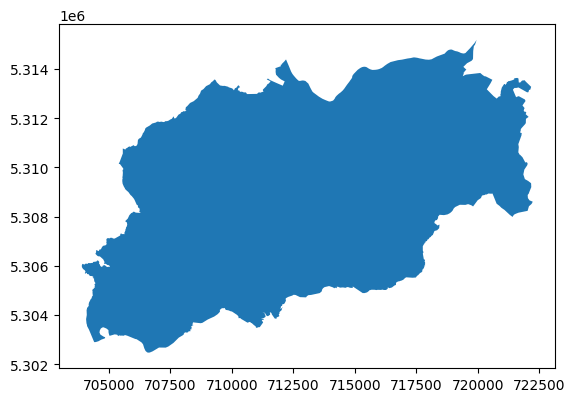

In [6]:
city_boundary = ox.geocode_to_gdf('Sighetu Marmației')
city_boundary = city_boundary.to_crs(epsg=32634)
city_boundary.to_file(f"{BASE_PATH}/00_Inventory_Preparation/city_boundary.shp")
city_boundary.plot()

<Axes: >

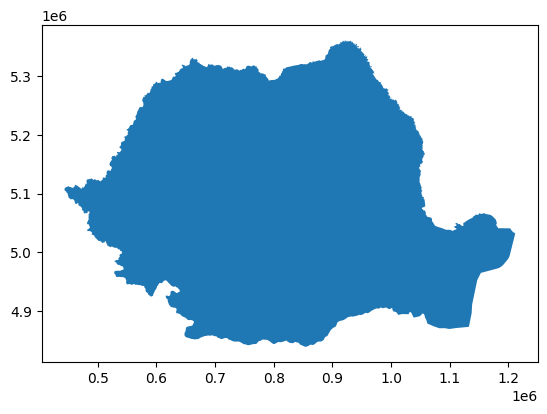

In [7]:
# Create the boundary of Romania
romania_boundary = ox.geocode_to_gdf('Romania')
romania_boundary = romania_boundary.to_crs(epsg=32634)
romania_boundary.to_file(f"{BASE_PATH}/00_Inventory_Preparation/romania_boundary.shp")
romania_boundary.plot()

<Axes: >

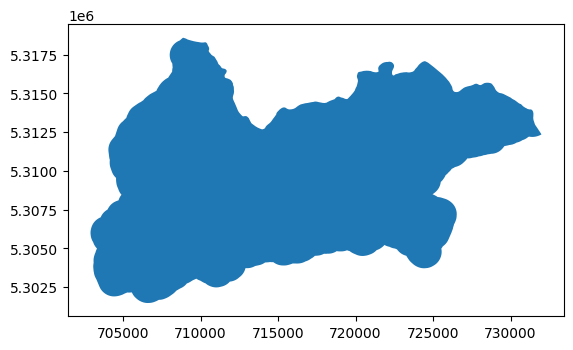

In [8]:
places = [
    "Sighetu Marmației, Romania",
    "Sarasău, Romania",
    "Vadu Izei, Romania",
    "Rona De Jos, Romania",
    "Bocicoiu Mare, Romania"
]

area_parts = ox.geocode_to_gdf(places)
area_parts = area_parts.to_crs(epsg=32634)

#Dissolve the areas into one polygon and buffer it

study_area_combined_geometry = area_parts.unary_union.buffer(1000)
study_area_gdf = gpd.GeoDataFrame(geometry=[study_area_combined_geometry], crs=area_parts.crs)

study_area_clipped = gpd.overlay(study_area_gdf, romania_boundary, how='intersection')
study_area_clipped.to_file(f"{BASE_PATH}/00_Inventory_Preparation/study_area_clipped.shp")

study_area_gdf.to_file(f"{BASE_PATH}/00_Inventory_Preparation/study_area.shp")
study_area_clipped.plot()

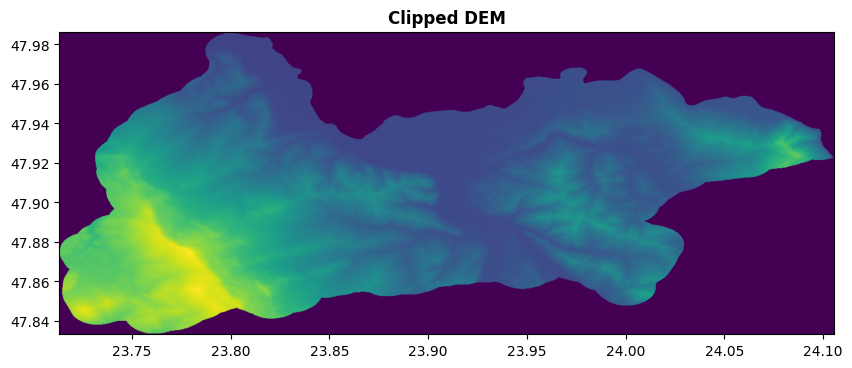

In [10]:
#Clipp the necessary DEM

with rasterio.open(f'{RAW_DATA}/DEM/raw_dem_elevation.tif') as src:
  study_area_clipped = study_area_clipped.to_crs(src.crs)

  shapes = [json.loads(study_area_clipped.to_json())['features'][0]['geometry']]

  out_image, out_transform = mask(src, shapes, crop=True)
  out_meta = src.meta.copy()


  out_meta.update({
      "driver": "GTiff",
      "height": out_image.shape[1],
      "width": out_image.shape[2],
      "transform": out_transform
  })

  output_path = '/content/drive/MyDrive/Landslide_CNN_Project/01_Raw_Data/DEM/clipped_dem.tif'
  with rasterio.open(output_path, "w", **out_meta) as dest:
    dest.write(out_image)

import matplotlib.pyplot as plt
import rasterio.plot

with rasterio.open(output_path) as clipped_src:
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    rasterio.plot.show(clipped_src, ax=ax, title="Clipped DEM")
    plt.show()

In [11]:
wbe = WbEnvironment()
wbe.working_directory = WBT_DIR
raster = wbe.read_raster(f"{RAW_DATA}/DEM/clipped_dem.tif")

In [12]:
#Smooth the actual raster

smoothed_raster = wbe.feature_preserving_smoothing(
    dem = raster,
    filter_size = 9
)
wbe.write_raster(smoothed_raster, f"{RAW_DATA}/DEM/smoothed_raster.tif")

In [13]:
m = leafmap.Map()
m.add_basemap('Satellite')
m.add_raster(f"{RAW_DATA}/DEM/clipped_dem.tif", cmap='terrain', layer_name='DEM')
m.add_gdf(gdf_metric)
m

Map(center=[47.909861, 23.909444], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title',…